# Анализ A/B/n-теста email-кампаний

## Цель исследования

Определить, увеличивают ли email-кампании посещаемость, конверсию и выручку интернет-магазина, сравнить две версии рассылки и сформулировать рекомендации по их дальнейшему использованию.

## Экспериментальные группы

- No E-Mail — контрольная группа, не получавшая письмо
- Mens E-Mail — группа, получившая письмо с мужскими товарами
- Womens E-Mail — группа, получившая письмо с женскими товарами

## Основные вопросы

1. Корректно ли пользователи распределились между группами?
2. Увеличивают ли рассылки посещаемость сайта?
3. Увеличивают ли рассылки конверсию в покупку?
4. Увеличивают ли рассылки выручку на пользователя?
5. Какую из двух email-кампаний стоит выбрать для общей аудитории?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
DATA_PATH = Path("../data/hillstrom.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## 1. Описание данных

Датасет содержит результаты рандомизированного эксперимента среди 64000 клиентов интернет-магазина. Каждый клиент был случайно определён в одну из трёх групп:

- No E-Mail — контрольная группа
- Mens E-Mail — рассылка с мужскими товарами
- Womens E-Mail — рассылка с женскими товарами

После отправки писем поведение клиентов отслеживалось в течение двух недель.

### Признаки до эксперимента

- recency — количество месяцев с последней покупки
- history_segment — категория клиента по сумме прошлых покупок
- history — сумма покупок клиента за прошлый год
- mens — покупал ли клиент мужские товары
- womens — покупал ли клиент женские товары
- zip_code — тип территории проживания
- newbie — является ли клиент новым
- channel — канал предыдущих покупок

### Экспериментальное воздействие

- segment — вариант email-кампании, назначенный клиенту

### Результаты эксперимента

- visit — посетил ли клиент сайт в течение двух недель
- conversion — совершил ли клиент покупку
- spend — сколько денег клиент потратил

In [3]:
print(f"Количество строк: {df.shape[0]:,}")
print(f"Количество столбцов: {df.shape[1]}")
print()
print("Столбцы:")
print(df.columns.tolist())

Количество строк: 64,000
Количество столбцов: 12

Столбцы:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 5.9 MB


In [5]:
missing_values = df.isna().sum()

missing_values

recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

In [6]:
categorical_columns = [
    "history_segment",
    "zip_code",
    "channel",
    "segment"
]

for column in categorical_columns:
    print(f"\nСтолбец: {column}")
    print(df[column].value_counts(dropna=False))


Столбец: history_segment
history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308
Name: count, dtype: int64

Столбец: zip_code
zip_code
Surburban    28776
Urban        25661
Rural         9563
Name: count, dtype: int64

Столбец: channel
channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64

Столбец: segment
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64


In [7]:
binary_columns = [
    "mens",
    "womens",
    "newbie",
    "visit",
    "conversion"
]

for column in binary_columns:
    print(f"{column}: {sorted(df[column].unique())}")

mens: [np.int64(0), np.int64(1)]
womens: [np.int64(0), np.int64(1)]
newbie: [np.int64(0), np.int64(1)]
visit: [np.int64(0), np.int64(1)]
conversion: [np.int64(0), np.int64(1)]


In [8]:
numeric_columns = [
    "recency",
    "history",
    "spend"
]

df[numeric_columns].describe().round(2)

,recency,history,spend
count,64000.00,64000.00,64000.00
mean,5.76,242.09,1.05
std,3.51,256.16,15.04
min,1.00,29.99,0.00
25%,2.00,64.66,0.00
50%,6.00,158.11,0.00
75%,9.00,325.66,0.00
max,12.00,3345.93,499.00


In [9]:
print(f"Полностью одинаковых строк: {df.duplicated().sum()}")

Полностью одинаковых строк: 6562


Дубликаты не удалялись, так как в данных нет user_id. Одинаковые строки могут принадлежать разным пользователям с совпадающими признаками.


## 2. Дизайн анализа эксперимента

### Экспериментальные группы

- No E-Mail — контрольная группа
- Mens E-Mail — тестовая группа с письмом о мужских товарах
- Womens E-Mail — тестовая группа с письмом о женских товарах

### Единица эксперимента

Единицей эксперимента является отдельный клиент. Согласно описанию данных, клиенты случайно распределялись между тремя экспериментальными группами.

### Основная метрика

$
RPU = \frac{\text{суммарные траты пользователей}}{\text{количество пользователей}}
$

В расчёт входят все пользователи, включая тех, кто ничего не купил.

### Дополнительные метрики

- visit rate — доля клиентов, посетивших сайт
- conversion rate — доля клиентов, совершивших покупку

### Статистические гипотезы

$
H_0: RPU_{test} = RPU_{control}
$

$
H_1: RPU_{test} \ne RPU_{control}
$

$
\alpha = 0.05
$

Для уменьшения вероятности ложноположительных результатов при нескольких сравнениях используется простая поправка Бонферрони: уровень значимости делится на количество проводимых сравнений

$
\alpha = \frac{0,05}{2}=0,025
$


### Проверка качества данных и размеров групп

In [10]:
logical_checks = {
    "Покупка без посещения сайта": (
        (df["conversion"] == 1) & (df["visit"] == 0)
    ).sum(),

    "Траты без покупки": (
        (df["spend"] > 0) & (df["conversion"] == 0)
    ).sum(),

    "Покупка с нулевыми тратами": (
        (df["conversion"] == 1) & (df["spend"] == 0)
    ).sum(),

    "Отрицательные траты": (
        df["spend"] < 0
    ).sum()
}

pd.Series(logical_checks, name="Количество строк")

Покупка без посещения сайта    0
Траты без покупки              0
Покупка с нулевыми тратами     0
Отрицательные траты            0
Name: Количество строк, dtype: int64

In [11]:
group_order = [
    "No E-Mail",
    "Mens E-Mail",
    "Womens E-Mail"
]

group_sizes = (
    df["segment"]
    .value_counts()
    .reindex(group_order)
    .rename("users")
    .to_frame()
)

group_sizes["share_percent"] = (
    group_sizes["users"] / len(df) * 100
).round(2)

group_sizes

,users,share_percent
segment,,
No E-Mail,21306,33.29
Mens E-Mail,21307,33.29
Womens E-Mail,21387,33.42


In [12]:
from scipy.stats import chisquare

observed = group_sizes["users"]
expected = [len(df) / 3] * 3

srm_stat, srm_pvalue = chisquare(observed, expected)

print(f"p-value SRM-проверки: {srm_pvalue:.4f}")

p-value SRM-проверки: 0.9037


В данных отсутствуют пропущенные значения и логические противоречия: покупка всегда сопровождается посещением сайта и положительными тратами. Отрицательных значений выручки не обнаружено.

В каждой экспериментальной группе находится примерно треть всех пользователей:

- No E-Mail — 21306 пользователей
- Mens E-Mail — 21307 пользователей
- Womens E-Mail — 21387 пользователей

Размеры групп практически одинаковы, p-value SRM-проверки больше 0,05, поэтому статистически значимого отклонения от ожидаемого равномерного распределения пользователей не обнаружено. Признаков ошибки при разделении пользователей на группы нет.

### Проверка баланса экспериментальных групп

In [13]:
pre_experiment_columns = [
    "recency",
    "history",
    "mens",
    "womens",
    "newbie"
]

balance_table = (
    df.groupby("segment")[pre_experiment_columns]
    .mean()
    .reindex(group_order)
    .round(3)
)

balance_table

,recency,history,mens,womens,newbie
segment,,,,,
No E-Mail,5.750,240.883,0.553,0.548,0.502
Mens E-Mail,5.774,242.836,0.551,0.551,0.502
Womens E-Mail,5.768,242.537,0.549,0.550,0.503


In [14]:
categorical_balance_columns = [
    "channel",
    "zip_code"
]

for column in categorical_balance_columns:
    print(f"\nРаспределение признака: {column}")

    distribution = (
        pd.crosstab(
            df["segment"],
            df[column],
            normalize="index"
        )
        .mul(100)
        .reindex(group_order)
        .round(2)
    )

    display(distribution)


Распределение признака: channel


channel,Multichannel,Phone,Web
segment,,,
No E-Mail,12.23,43.78,43.99
Mens E-Mail,12.09,43.37,44.54
Womens E-Mail,12.06,44.20,43.74



Распределение признака: zip_code


zip_code,Rural,Surburban,Urban
segment,,,
No E-Mail,14.73,45.18,40.09
Mens E-Mail,15.22,44.59,40.19
Womens E-Mail,14.87,45.12,40.01


Перед сравнением результатов были рассмотрены характеристики пользователей, измеренные до начала рассылки.

Средние значения давности последней покупки, суммы предыдущих покупок, доли новых клиентов и истории покупок различных категорий близки во всех трёх группах.

Распределения пользователей по каналам предыдущих покупок и типам территории также практически не различаются.

Заметных исходных различий между группами не обнаружено, поэтому можно переходить к сравнению результатов email-кампаний.

## 3. Предварительный анализ результатов

In [15]:
experiment_summary = (
    df.groupby("segment")
    .agg(
        users=("segment", "size"),
        visits=("visit", "sum"),
        visit_rate=("visit", "mean"),
        conversions=("conversion", "sum"),
        conversion_rate=("conversion", "mean"),
        total_revenue=("spend", "sum"),
        revenue_per_user=("spend", "mean"),
        spend_per_buyer=(
            "spend",
            lambda values: values[values > 0].mean()
        )
    )
    .reindex(group_order)
)

In [16]:
summary_display = experiment_summary.copy()

summary_display["visit_rate"] = (
    summary_display["visit_rate"] * 100
)

summary_display["conversion_rate"] = (
    summary_display["conversion_rate"] * 100
)

summary_display = summary_display.round({
    "visit_rate": 2,
    "conversion_rate": 2,
    "total_revenue": 2,
    "revenue_per_user": 3,
    "spend_per_buyer": 2
})

summary_display

,users,visits,visit_rate,conversions,conversion_rate,total_revenue,revenue_per_user,spend_per_buyer
segment,,,,,,,,
No E-Mail,21306,2262,10.62,122,0.57,13908.33,0.653,114.00
Mens E-Mail,21307,3894,18.28,267,1.25,30311.69,1.423,113.53
Womens E-Mail,21387,3238,15.14,189,0.88,23038.11,1.077,121.89


Средние траты среди покупателей составили 114,00 в контрольной группе, 113,53 в Mens E-Mail и 121,89 в Womens E-Mail. Следовательно, рост RPU в Mens E-Mail связан в основном с увеличением конверсии, а не с ростом суммы трат одного покупателя.

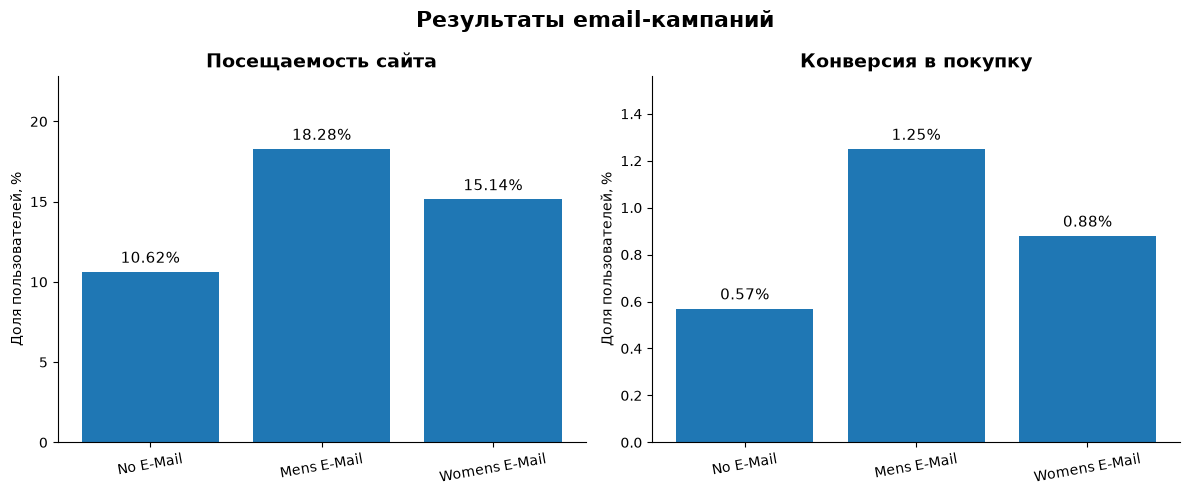

In [17]:
images_path = Path("../images")
images_path.mkdir(exist_ok=True)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

metrics_to_plot = [
    ("visit_rate", "Посещаемость сайта"),
    ("conversion_rate", "Конверсия в покупку")
]

for ax, (metric, title) in zip(
    axes,
    metrics_to_plot
):
    values = summary_display.loc[
        group_order,
        metric
    ]

    bars = ax.bar(
        group_order,
        values
    )

    ax.bar_label(
        bars,
        labels=[
            f"{value:.2f}%"
            for value in values
        ],
        padding=4,
        fontsize=11
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_ylabel("Доля пользователей, %")
    ax.set_ylim(0, values.max() * 1.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=10)

fig.suptitle(
    "Результаты email-кампаний",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    images_path / "group_metrics.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [18]:
def calculate_uplift(test_value, control_value):
    absolute_uplift = test_value - control_value
    relative_uplift = (
        test_value / control_value - 1
    ) * 100

    return absolute_uplift, relative_uplift

In [19]:
metrics = [
    "visit_rate",
    "conversion_rate",
    "revenue_per_user"
]

uplift_results = []

for campaign in ["Mens E-Mail", "Womens E-Mail"]:
    for metric in metrics:
        control_value = experiment_summary.loc[
            "No E-Mail", metric
        ]

        test_value = experiment_summary.loc[
            campaign, metric
        ]

        absolute_uplift, relative_uplift = calculate_uplift(
            test_value,
            control_value
        )

        uplift_results.append({
            "campaign": campaign,
            "metric": metric,
            "control_value": control_value,
            "test_value": test_value,
            "absolute_uplift": absolute_uplift,
            "relative_uplift_percent": relative_uplift
        })

uplift_table = pd.DataFrame(uplift_results)

uplift_table.round(4)

,campaign,metric,control_value,test_value,absolute_uplift,relative_uplift_percent
0,Mens E-Mail,visit_rate,0.1062,0.1828,0.0766,72.1405
1,Mens E-Mail,conversion_rate,0.0057,0.0125,0.0068,118.8422
2,Mens E-Mail,revenue_per_user,0.6528,1.4226,0.7698,117.9289
3,Womens E-Mail,visit_rate,0.1062,0.1514,0.0452,42.6055
4,Womens E-Mail,conversion_rate,0.0057,0.0088,0.0031,54.3313
5,Womens E-Mail,revenue_per_user,0.6528,1.0772,0.4244,65.0152


Обе email-кампании показали более высокие наблюдаемые значения посещаемости, конверсии и выручки на пользователя по сравнению с 
контрольной группой.
Наиболее высокие значения всех трёх метрик наблюдаются у кампании Mens E-Mail:

- visit rate увеличился с 10,62% до 18,28%
- conversion rate увеличился с 0,57% до 1,25%
- RPU увеличился с 0,653 до 1,423

Кампания Womens E-Mail также показывает положительный наблюдаемый эффект, но его величина ниже:

- visit rate составил 15,14%
- conversion rate составил 0,88%
- RPU составил 1,077

На этом этапе нельзя утверждать, что различия вызваны email-кампаниями. Далее необходимо оценить статистическую значимость и доверительные интервалы полученных эффектов.

## 4. Статистический анализ

### Влияние кампаний на RPU

Для сравнения средней выручки на пользователя использован t-тест Уэлча, потому что он сравнивает средние значения двух независимых групп и не требует, чтобы разброс выручки в группах был одинаковым.

In [20]:
def compare_revenue_per_user(
    data,
    control_name,
    test_name
):
    control_values = data.loc[
        data["segment"] == control_name,
        "spend"
    ]

    test_values = data.loc[
        data["segment"] == test_name,
        "spend"
    ]

    control_rpu = control_values.mean()
    test_rpu = test_values.mean()

    absolute_uplift = test_rpu - control_rpu

    relative_uplift = (
        test_rpu / control_rpu - 1
    ) * 100

    welch_result = stats.ttest_ind(
        test_values,
        control_values,
        equal_var=False,
        alternative="two-sided"
    )

    confidence_interval = welch_result.confidence_interval(
        confidence_level=0.95
    )

    return {
        "campaign": test_name,
        "control_rpu": control_rpu,
        "test_rpu": test_rpu,
        "absolute_uplift": absolute_uplift,
        "relative_uplift_percent": relative_uplift,
        "ci_lower": confidence_interval.low,
        "ci_upper": confidence_interval.high,
        "p_value": welch_result.pvalue
    }

In [21]:
revenue_results = []

for campaign in [
    "Mens E-Mail",
    "Womens E-Mail"
]:
    result = compare_revenue_per_user(
        data=df,
        control_name="No E-Mail",
        test_name=campaign
    )

    revenue_results.append(result)

revenue_test_table = pd.DataFrame(
    revenue_results
)

revenue_test_table["significant"] = (
    revenue_test_table["p_value"] < 0.025
)

revenue_test_table.round(4)

,campaign,control_rpu,test_rpu,absolute_uplift,relative_uplift_percent,ci_lower,ci_upper,p_value,significant
0,Mens E-Mail,0.6528,1.4226,0.7698,117.9289,0.4851,1.0545,0.0000,True
1,Womens E-Mail,0.6528,1.0772,0.4244,65.0152,0.1690,0.6799,0.0011,True


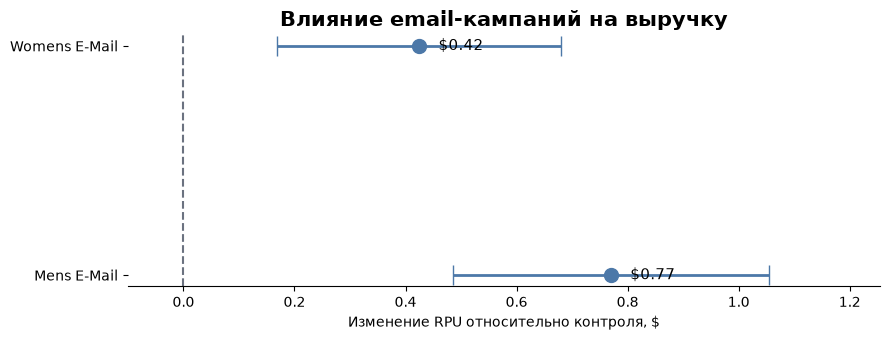

In [22]:
rpu_plot_data = (
    revenue_test_table
    .set_index("campaign")
    .loc[["Mens E-Mail", "Womens E-Mail"]]
)

effects = rpu_plot_data["absolute_uplift"].to_numpy()
lower_errors = (
    effects
    - rpu_plot_data["ci_lower"].to_numpy()
)
upper_errors = (
    rpu_plot_data["ci_upper"].to_numpy()
    - effects
)

y_positions = np.arange(
    len(rpu_plot_data)
)

fig, ax = plt.subplots(figsize=(9, 3.5))

ax.errorbar(
    effects,
    y_positions,
    xerr=[lower_errors, upper_errors],
    fmt="o",
    markersize=10,
    capsize=7,
    linewidth=2,
    color="#4C78A8",
    ecolor="#4C78A8"
)

ax.axvline(
    0,
    color="#6B7280",
    linestyle="--",
    linewidth=1.5
)

for position, effect in zip(
    y_positions,
    effects
):
    ax.text(
        effect + 0.035,
        position,
        f"${effect:.2f}",
        va="center",
        fontsize=11
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(rpu_plot_data.index)
ax.set_xlabel(
    "Изменение RPU относительно контроля, $"
)
ax.set_title(
    "Влияние email-кампаний на выручку",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlim(
    min(-0.1, rpu_plot_data["ci_lower"].min() - 0.1),
    rpu_plot_data["ci_upper"].max() + 0.2
)

ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()

plt.savefig(
    images_path / "rpu_uplift_ci.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Кампания Mens E-Mail:

- увеличила RPU с 0,653 до 1,423
- абсолютный прирост составил 0,770 на пользователя
- относительный прирост составил 117,9%
- 95% доверительный интервал прироста: от 0,485 до 1,055
- p-value меньше 0,0001

Кампания Womens E-Mail:

- увеличила RPU с 0,653 до 1,077
- абсолютный прирост составил 0,424 на пользователя
- относительный прирост составил 65,0%
- 95% доверительный интервал прироста: от 0,169 до 0,680
- p-value составляет 0,0011

Поскольку проводятся два сравнения с контрольной группой, используется уровень значимости:

$
\alpha = \frac{0,05}{2}=0,025
$

Оба p-value меньше 0,025, а доверительные интервалы не содержат ноль. Следовательно, обе кампании статистически значимо увеличили среднюю выручку на пользователя.

### Прямое сравнение email-кампаний

In [23]:
direct_revenue_result = compare_revenue_per_user(
    data=df,
    control_name="Womens E-Mail",
    test_name="Mens E-Mail"
)

pd.DataFrame([direct_revenue_result]).round(4)

,campaign,control_rpu,test_rpu,absolute_uplift,relative_uplift_percent,ci_lower,ci_upper,p_value
0,Mens E-Mail,1.0772,1.4226,0.3454,32.066,0.0326,0.6583,0.0305


RPU кампании Mens E-Mail составил 1,423, а RPU кампании Womens E-Mail — 1,077.

Разница в пользу Mens E-Mail составила:

$
1,423-1,077=0,345
$

на одного пользователя.

95% доверительный интервал разницы составляет от 0,033 до 0,658, p-value - 0,0305. Однако после поправки Бонферрони различие между двумя кампаниями не является статистически значимым. Поэтому Mens E-Mail показывает лучший наблюдаемый результат, но её превосходство над Womens E-Mail нельзя считать окончательно подтверждённым.

### Дополнительные метрики: посещаемость и конверсия

Для сравнения долей используется z-тест, поскольку обе метрики бинарные, а размеры независимых групп достаточно большие.

In [24]:
def compare_proportions(
    data,
    control_name,
    test_name,
    metric,
    alpha=0.05
):
    control = data[data["segment"] == control_name][metric]
    test = data[data["segment"] == test_name][metric]

    control_successes = control.sum()
    test_successes = test.sum()

    control_size = control.size
    test_size = test.size

    control_rate = control.mean()
    test_rate = test.mean()

    counts = np.array([
        test_successes,
        control_successes
    ])

    observations = np.array([
        test_size,
        control_size
    ])

    z_statistic, p_value = proportions_ztest(
        count=counts,
        nobs=observations,
        alternative="two-sided"
    )

    absolute_uplift = test_rate - control_rate

    standard_error = np.sqrt(
        test_rate * (1 - test_rate) / test_size
        + control_rate * (1 - control_rate) / control_size
    )

    critical_value = stats.norm.ppf(
        1 - alpha / 2
    )

    ci_lower = (
        absolute_uplift
        - critical_value * standard_error
    )

    ci_upper = (
        absolute_uplift
        + critical_value * standard_error
    )

    relative_uplift = (
        test_rate / control_rate - 1
    ) * 100

    return {
        "campaign": test_name,
        "metric": metric,
        "control_rate_percent": control_rate * 100,
        "test_rate_percent": test_rate * 100,
        "absolute_uplift_pp": absolute_uplift * 100,
        "relative_uplift_percent": relative_uplift,
        "ci_lower_pp": ci_lower * 100,
        "ci_upper_pp": ci_upper * 100,
        "z_statistic": z_statistic,
        "p_value": p_value
    }

In [25]:
proportion_results = []

for campaign in [
    "Mens E-Mail",
    "Womens E-Mail"
]:
    for metric in [
        "visit",
        "conversion"
    ]:
        result = compare_proportions(
            data=df,
            control_name="No E-Mail",
            test_name=campaign,
            metric=metric
        )

        proportion_results.append(result)

proportion_test_table = pd.DataFrame(
    proportion_results
)

proportion_test_table.round(4)

,campaign,metric,control_rate_percent,test_rate_percent,absolute_uplift_pp,relative_uplift_percent,ci_lower_pp,ci_upper_pp,z_statistic,p_value
0,Mens E-Mail,visit,10.6167,18.2757,7.6590,72.1405,6.9954,8.3226,22.4860,0.0000
1,Mens E-Mail,conversion,0.5726,1.2531,0.6805,118.8422,0.5000,0.8610,7.3851,0.0000
2,Womens E-Mail,visit,10.6167,15.1400,4.5233,42.6055,3.8894,5.1572,13.9492,0.0000
3,Womens E-Mail,conversion,0.5726,0.8837,0.3111,54.3313,0.1499,0.4723,3.7796,0.0002


In [26]:
alpha = 0.05
number_of_tests = len(proportion_test_table)

bonferroni_alpha = alpha / number_of_tests

proportion_test_table["significant"] = (
    proportion_test_table["p_value"] < bonferroni_alpha
)

print(
    f"Скорректированный уровень значимости: "
    f"{bonferroni_alpha:.4f}"
)

columns_to_show = [
    "campaign",
    "metric",
    "control_rate_percent",
    "test_rate_percent",
    "absolute_uplift_pp",
    "relative_uplift_percent",
    "ci_lower_pp",
    "ci_upper_pp",
    "p_value",
    "significant"
]

proportion_test_table[
    columns_to_show
].round(5)

Скорректированный уровень значимости: 0.0125


,campaign,metric,control_rate_percent,test_rate_percent,absolute_uplift_pp,relative_uplift_percent,ci_lower_pp,ci_upper_pp,p_value,significant
0,Mens E-Mail,visit,10.61673,18.27568,7.65896,72.14046,6.99535,8.32256,0.00000,True
1,Mens E-Mail,conversion,0.57261,1.25311,0.68050,118.84219,0.50002,0.86098,0.00000,True
2,Womens E-Mail,visit,10.61673,15.14004,4.52331,42.60551,3.88938,5.15724,0.00000,True
3,Womens E-Mail,conversion,0.57261,0.88371,0.31111,54.33130,0.14987,0.47234,0.00016,True


Обе email-кампании показали статистически значимое увеличение посещаемости сайта и конверсии в покупку относительно контрольной группы.

Кампания Mens E-Mail показала наиболее сильный эффект:

- visit rate увеличился на 7,66 пп, 95% ДИ [7,00; 8,32]
- conversion rate увеличился на 0,68 пп, 95% ДИ [0,50; 0,86]

Кампания Womens E-Mail также показала положительный эффект:

- visit rate увеличился на 4,52 пп, 95% ДИ [3,89; 5,16]
- conversion rate увеличился на 0,31 пп, 95% ДИ [0,15; 0,47]

Для четырёх сравнений использован скорректированный уровень значимости:

$
\alpha = \frac{0,05}{4}=0,0125
$

Все полученные p-value меньше скорректированного уровня значимости.

## 5. Оценка бизнес-эффекта

Чтобы представить результат в бизнес-терминах, эффект был масштабирован на гипотетическую аудиторию из 100 000 пользователей.

In [27]:
audience_size = 100_000

business_impact = (
    revenue_test_table[
        [
            "campaign",
            "absolute_uplift",
            "ci_lower",
            "ci_upper"
        ]
    ]
    .copy()
)

business_impact[
    "audience_size"
] = audience_size

business_impact[
    "expected_incremental_revenue"
] = (
    business_impact["absolute_uplift"]
    * audience_size
)

business_impact[
    "ci_lower_revenue"
] = (
    business_impact["ci_lower"]
    * audience_size
)

business_impact[
    "ci_upper_revenue"
] = (
    business_impact["ci_upper"]
    * audience_size
)

columns_to_show = [
    "campaign",
    "audience_size",
    "expected_incremental_revenue",
    "ci_lower_revenue",
    "ci_upper_revenue"
]

business_impact[
    columns_to_show
].round(2)

,campaign,audience_size,expected_incremental_revenue,ci_lower_revenue,ci_upper_revenue
0,Mens E-Mail,100000,76982.72,48513.97,105451.46
1,Womens E-Mail,100000,42441.22,16895.68,67986.76


In [28]:
mens_over_womens_impact = pd.DataFrame({
    "metric": ["Additional RPU"],
    "mens_minus_womens": [
        direct_revenue_result["absolute_uplift"]
    ],
    "ci_lower": [
        direct_revenue_result["ci_lower"]
    ],
    "ci_upper": [
        direct_revenue_result["ci_upper"]
    ],
    "additional_revenue_per_100k": [
        direct_revenue_result["absolute_uplift"]
        * audience_size
    ],
    "ci_lower_revenue_per_100k": [
        direct_revenue_result["ci_lower"]
        * audience_size
    ],
    "ci_upper_revenue_per_100k": [
        direct_revenue_result["ci_upper"]
        * audience_size
    ]
})

mens_over_womens_impact.round(2)

,metric,mens_minus_womens,ci_lower,ci_upper,additional_revenue_per_100k,ci_lower_revenue_per_100k,ci_upper_revenue_per_100k
0,Additional RPU,0.35,0.03,0.66,34541.49,3256.14,65826.84


### Сравнение с отсутствием рассылки

Для кампании Mens E-Mail:

- ожидаемая дополнительная выручка составляет около 76983
- 95% доверительный интервал от 48514 до 105 451

Для кампании Womens E-Mail:

- ожидаемая дополнительная выручка составляет около 42441
- 95% доверительный интервал от 16896 до 67987

### Сравнение двух кампаний

Обе кампании статистически значимо увеличивают RPU относительно отсутствия рассылки. Mens E-Mail показала наибольший наблюдаемый эффект и выглядит наиболее перспективной, однако её превосходство над Womens E-Mail требует дополнительной проверки.

### Бизнес-рекомендация

Если необходимо выбрать только одну кампанию для всей аудитории, предпочтительным вариантом является Mens E-Mail, так как он показал самый высокий visit rate, conversion rate, revenue per user и имеет статистически значимое преимущество по RPU относительно отсутствия рассылки.

### Ограничения

Полученные значения отражают дополнительную выручку, а не прибыль. Датасет не содержит информации о себестоимости товаров, маржинальности бизнеса и стоимости отправки писем.

Поэтому перед запуском кампании необходимо сравнить ожидаемую дополнительную выручку с расходами и рассчитать прирост прибыли.

Масштабирование на 100 000 пользователей также предполагает, что новая аудитория похожа на участников эксперимента и эффект кампании сохранится при увеличении объёма рассылки.